<a href="https://colab.research.google.com/github/jasonkjw/daily_coding_commit/blob/main/FRS_TH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
성공: /content/drive/MyDrive/FRS_Analysis/EW_FRS.csv 파일을 불러왔습니다.
반복 보정 수행 중...
가속도 시간이력 저장 완료: /content/drive/MyDrive/FRS_Analysis/generated_th.csv


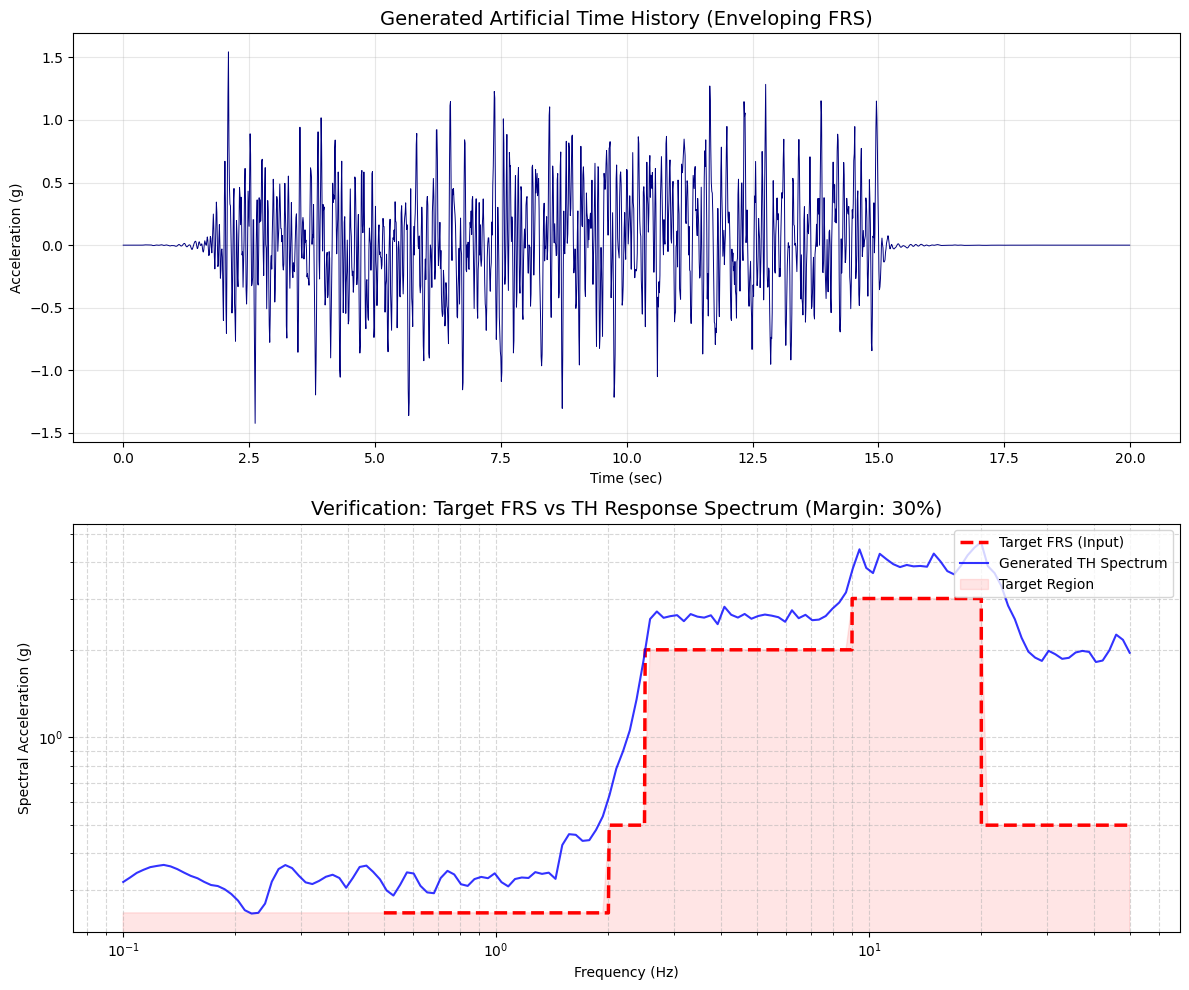

검증 그래프 저장 완료: /content/drive/MyDrive/FRS_Analysis/frs_verification.png


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq
from google.colab import drive
import os

# --- 1. 구글 드라이브 마운트 ---
drive.mount('/content/drive')
working_dir = '/content/drive/MyDrive/FRS_Analysis'
if not os.path.exists(working_dir):
    os.makedirs(working_dir)

input_csv = os.path.join(working_dir, 'EW_FRS.csv')
output_csv = os.path.join(working_dir, 'generated_th.csv')
output_plot = os.path.join(working_dir, 'frs_verification.png')

# --- 2. 목표 FRS 로드 및 설정 ---
try:
    df_target = pd.read_csv(input_csv)
    print(f"성공: {input_csv} 파일을 불러왔습니다.")
except FileNotFoundError:
    print("파일을 찾을 수 없습니다.")

def get_target_accel(freq, df_target):
    return np.interp(freq, df_target['Frequency'], df_target['Acceleration'])

def calculate_response_spectrum(accel_th, dt, frequencies, damping=0.05):
    n = len(accel_th)
    spectrum = []
    beta, gamma = 1/4, 1/2  # Newmark-beta (Average Accel)

    for f in frequencies:
        omega = 2 * np.pi * f
        c, k, m = 2 * damping * omega, omega**2, 1.0
        u, v = 0.0, 0.0
        a = (-accel_th[0] - c*v - k*u) / m
        max_abs_accel = 0.0

        for i in range(n - 1):
            p1, p0 = -accel_th[i+1], -accel_th[i]
            k_hat = k + (gamma / (beta * dt)) * c + (1 / (beta * dt**2)) * m
            du_force = (p1 - p0) + (m / (beta * dt) + (gamma / beta) * c) * v + \
                       (m / (2 * beta) + dt * (gamma / (2 * beta) - 1) * c) * a
            du = du_force / k_hat
            dv = (gamma / (beta * dt)) * du - (gamma / beta) * v + dt * (1 - gamma / (2 * beta)) * a
            da = (1 / (beta * dt**2)) * du - (1 / (beta * dt)) * v - (1 / (2 * beta)) * a
            u, v, a = u+du, v+dv, a+da
            abs_accel = abs(a + accel_th[i+1])
            if abs_accel > max_abs_accel: max_abs_accel = abs_accel
        spectrum.append(max_abs_accel)
    return np.array(spectrum)

# --- 3. 인공지진파 생성 파라미터 ---
dt = 0.01
duration = 20.0
t = np.arange(0, duration, dt)
n_pts = len(t)
damping = 0.05
iterations = 15     # 보정 반복 횟수
margin_factor = 1.3 # 목표 FRS 대비 30% 상향 목표 (Enveloping 보장용)

target_freqs = np.logspace(np.log10(0.1), np.log10(50), 150)
target_accels = get_target_accel(target_freqs, df_target)

# 초기 Seed (White Noise + Trapezoidal Envelope)
np.random.seed(42)
envelope = np.ones_like(t)
envelope[t < 2.0] = t[t < 2.0] / 2.0
envelope[t > 15.0] = np.exp(-1.0 * (t[t > 15.0] - 15.0))
th = np.random.normal(0, 0.5, n_pts) * envelope

# --- 4. 반복 보정 로직 (Spectral Matching) ---
print("반복 보정 수행 중...")
for it in range(iterations):
    current_spectrum = calculate_response_spectrum(th, dt, target_freqs, damping)

    # 목표치보다 낮은 구간은 강하게 보정, 높은 구간은 완만하게 유지
    ratio = (target_accels * margin_factor) / current_spectrum
    ratio = np.maximum(ratio, 0.9) # 급격한 감소 방지

    th_fft = fft(th)
    freqs_fft = fftfreq(n_pts, dt)
    ratio_interp = np.interp(np.abs(freqs_fft), target_freqs, ratio, left=1.0, right=1.0)

    th = np.real(ifft(th_fft * ratio_interp))
    th = th * envelope # 시간축 외포선 재적용

# 최종 검증 스펙트럼 계산
final_spectrum = calculate_response_spectrum(th, dt, target_freqs, damping)

# --- 5. 결과 저장 및 시각화 ---
df_th_final = pd.DataFrame({'Time': t, 'Acceleration_g': th})
df_th_final.to_csv(output_csv, index=False)
print(f"가속도 시간이력 저장 완료: {output_csv}")

plt.figure(figsize=(12, 10))

# Time History Plot
plt.subplot(2, 1, 1)
plt.plot(t, th, lw=0.7, color='navy')
plt.title('Generated Artificial Time History (Enveloping FRS)', fontsize=14)
plt.xlabel('Time (sec)'); plt.ylabel('Acceleration (g)')
plt.grid(True, alpha=0.3)

# Spectrum Comparison Plot
plt.subplot(2, 1, 2)
plt.loglog(df_target['Frequency'], df_target['Acceleration'], 'r--', label='Target FRS (Input)', lw=2.5)
plt.loglog(target_freqs, final_spectrum, 'b-', label='Generated TH Spectrum', alpha=0.8)
# 포괄 영역 시각화 (Target 미달 여부 확인용)
plt.fill_between(target_freqs, 0, target_accels, color='red', alpha=0.1, label='Target Region')

plt.title(f'Verification: Target FRS vs TH Response Spectrum (Margin: {int((margin_factor-1)*100)}%)', fontsize=14)
plt.xlabel('Frequency (Hz)'); plt.ylabel('Spectral Acceleration (g)')
plt.legend(loc='upper right'); plt.grid(True, which='both', ls='--', alpha=0.5)

plt.tight_layout()
plt.savefig(output_plot)
plt.show()

print(f"검증 그래프 저장 완료: {output_plot}")